# Inference & Regression

Full explanation, reasoning, and write-up: see **Inference_Regression_Detailed_Explanation.docx**

1. Chi-square — Hotel vs. Cancellation
2. Chi-square — Deposit Type vs. Cancellation
3. Permutation test — LeadTime vs. Cancellation
4. Linear Regression — ADR


 0. Setup

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (8, 5)
np.random.seed(42)

1. Load data

In [3]:
import os

processed_path = "../data/processed/hotel_bookings_cleaned.csv"

if not os.path.exists(processed_path):
    raise FileNotFoundError(
        "data/processed/hotel_bookings_cleaned.csv not found. "
        
    )

df = pd.read_csv(processed_path)
print(f"Loaded cleaned dataset: {df.shape}")

FIG_DIR = "../outputs/figures"
os.makedirs(FIG_DIR, exist_ok=True)

df.head()


Loaded cleaned dataset: (87396, 36)


,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,Babies,Meal,Country,MarketSegment,DistributionChannel,IsRepeatedGuest,PreviousCancellations,PreviousBookingsNotCanceled,ReservedRoomType,AssignedRoomType,BookingChanges,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate,Hotel,ArrivalDate,TotalNights,TotalGuests,LeadTimeBand
0,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,Not Applicable,Not Applicable,0,Transient,0.0,0,0,Check-Out,2015-07-01,Resort Hotel,2015-07-01,0,2.0,6mo+
1,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,Not Applicable,Not Applicable,0,Transient,0.0,0,0,Check-Out,2015-07-01,Resort Hotel,2015-07-01,0,2.0,6mo+
2,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,Not Applicable,Not Applicable,0,Transient,75.0,0,0,Check-Out,2015-07-02,Resort Hotel,2015-07-01,1,1.0,0-7d
3,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304,Not Applicable,0,Transient,75.0,0,0,Check-Out,2015-07-02,Resort Hotel,2015-07-01,1,1.0,1-4wk
4,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240,Not Applicable,0,Transient,98.0,0,1,Check-Out,2015-07-03,Resort Hotel,2015-07-01,2,2.0,1-4wk


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 87396 entries, 0 to 87395
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   IsCanceled                   87396 non-null  int64  
 1   LeadTime                     87396 non-null  int64  
 2   ArrivalDateYear              87396 non-null  int64  
 3   ArrivalDateMonth             87396 non-null  str    
 4   ArrivalDateWeekNumber        87396 non-null  int64  
 5   ArrivalDateDayOfMonth        87396 non-null  int64  
 6   StaysInWeekendNights         87396 non-null  int64  
 7   StaysInWeekNights            87396 non-null  int64  
 8   Adults                       87396 non-null  int64  
 9   Children                     87396 non-null  float64
 10  Babies                       87396 non-null  int64  
 11  Meal                         87396 non-null  str    
 12  Country                      87396 non-null  str    
 13  MarketSegment              

## 2. Chi-square Test 1 — Hotel vs. Cancellation
- H0: Hotel type & cancellation are independent
- H1: Hotel type & cancellation are associated


**Method:** Chi-square test of independence on the 2×2 contingency table (Hotel × IsCanceled).

In [5]:
table1 = pd.crosstab(df["Hotel"], df["IsCanceled"])
print("Observed counts:")
print(table1)

chi2_1, p1, dof1, expected1 = stats.chi2_contingency(table1)

print(f"\nchi2 statistic = {chi2_1:.3f}")
print(f"degrees of freedom = {dof1}")
print(f"p-value = {p1:.4g}")
print("\nExpected counts (if independent):")
print(pd.DataFrame(expected1, index=table1.index, columns=table1.columns).round(1))

# Effect size: Cramer's V
n1 = table1.to_numpy().sum()
r1, k1 = table1.shape
cramers_v1 = np.sqrt(chi2_1 / (n1 * min(r1 - 1, k1 - 1)))
print(f"Cramer's V: {cramers_v1:.4f}")

Observed counts:
IsCanceled        0      1
Hotel                     
City Hotel    37379  16049
Resort Hotel  25992   7976

chi2 statistic = 447.664
degrees of freedom = 1
p-value = 2.326e-99

Expected counts (if independent):
IsCanceled          0        1
Hotel                         
City Hotel    38740.7  14687.3
Resort Hotel  24630.3   9337.7
Cramer's V: 0.0716


Cancellation rate by hotel (%):
Hotel
City Hotel      30.04
Resort Hotel    23.48
Name: 1, dtype: float64

Difference in cancellation rate: 6.56 percentage points


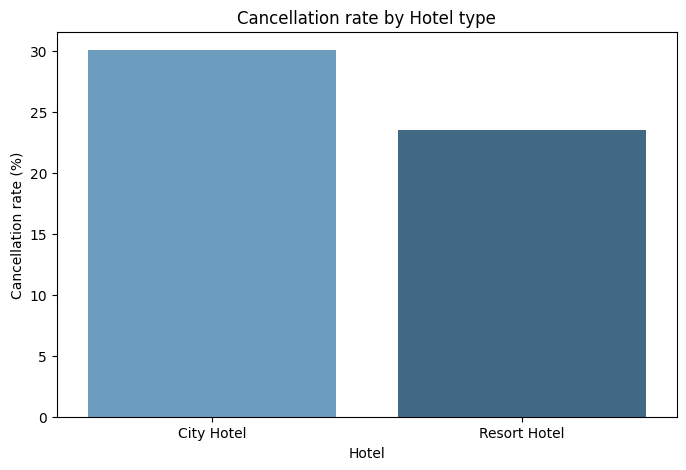

In [6]:
# Effect size: cancellation rate by hotel
rate_by_hotel = table1.div(table1.sum(axis=1), axis=0)[1] * 100
print("Cancellation rate by hotel (%):")
print(rate_by_hotel.round(2))

diff = rate_by_hotel.iloc[1] - rate_by_hotel.iloc[0] if len(rate_by_hotel) == 2 else None
print(f"\nDifference in cancellation rate: {abs(diff):.2f} percentage points" if diff is not None else "")

sns.barplot(x=rate_by_hotel.index, y=rate_by_hotel.values, hue=rate_by_hotel.index, palette="Blues_d", legend=False)
plt.ylabel("Cancellation rate (%)")
plt.title("Cancellation rate by Hotel type")
plt.savefig(f"{FIG_DIR}/chisq_hotel_cancellation.png", bbox_inches="tight", dpi=120)
plt.show()

**Result:** χ² = 447.664, p = 2.326e-99, Cramér's V = 0.0716 (weak) → significant but weak. City Hotel 30.04% vs Resort 23.48% (6.56pp gap).


## 3. Chi-square Test 2 — Deposit Type vs. Cancellation
- H0: Deposit type & cancellation are independent
- H1: Deposit type & cancellation are associated


**Method:** Chi-square test of independence, with attention to rare categories (expected cell counts should generally be ≥ 5 for the test to be reliable).

In [8]:
table2 = pd.crosstab(df["DepositType"], df["IsCanceled"])
print("Observed counts:")
print(table2)

chi2_2, p2, dof2, expected2 = stats.chi2_contingency(table2)

print(f"\nchi2 statistic = {chi2_2:.3f}")
print(f"degrees of freedom = {dof2}")
print(f"p-value = {p2:.4g}")

expected2_df = pd.DataFrame(expected2, index=table2.index, columns=table2.columns).round(1)
print("\nExpected counts:")
print(expected2_df)

low_cells = (expected2_df < 5).values.any()
print(f"\nAny expected cell count below 5? {low_cells} ")

# Effect size: Cramer's V
n2 = table2.to_numpy().sum()
r2, k2 = table2.shape
cramers_v2 = np.sqrt(chi2_2 / (n2 * min(r2 - 1, k2 - 1)))
print(f"Cramer's V: {cramers_v2:.4f}")

Observed counts:
IsCanceled       0      1
DepositType              
No Deposit   63235  23016
Non Refund      55    983
Refundable      81     26

chi2 statistic = 2380.996
degrees of freedom = 2
p-value = 0

Expected counts:
IsCanceled         0        1
DepositType                  
No Deposit   62540.8  23710.2
Non Refund     752.7    285.3
Refundable      77.6     29.4

Any expected cell count below 5? False 
Cramer's V: 0.1651


Cancellation rate by deposit type (%):
DepositType
Non Refund    94.70
No Deposit    26.68
Refundable    24.30
Name: 1, dtype: float64


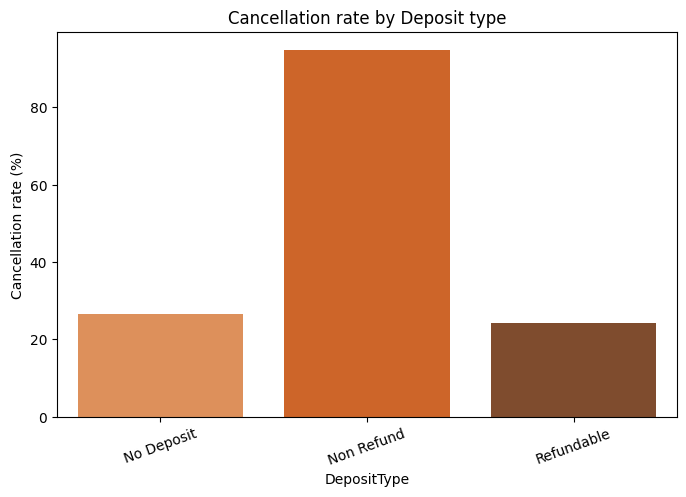

In [9]:
rate_by_deposit = table2.div(table2.sum(axis=1), axis=0)[1] * 100
print("Cancellation rate by deposit type (%):")
print(rate_by_deposit.sort_values(ascending=False).round(2))

sns.barplot(x=rate_by_deposit.index, y=rate_by_deposit.values, hue=rate_by_deposit.index, palette="Oranges_d", legend=False)
plt.ylabel("Cancellation rate (%)")
plt.title("Cancellation rate by Deposit type")
plt.xticks(rotation=20)
plt.savefig(f"{FIG_DIR}/chisq_deposit_cancellation.png", bbox_inches="tight", dpi=120)
plt.show()

**Result:** χ² = 2380.996, p ≈ 0, Cramér's V = 0.1651 (moderate) → significant, stronger than hotel test. Non Refund 94.70% vs No Deposit 26.68% vs Refundable 24.30% (counterintuitive).


## 4. Permutation Test — LeadTime vs. Cancellation

**Question:** Is the mean LeadTime different between cancelled and non-cancelled bookings?

**Method:** Permutation test — build the null distribution by randomly shuffling the cancellation
labels thousands of times and recomputing the difference in mean LeadTime each time. This constructs
the null distribution directly instead of relying on a parametric assumption (useful here since LeadTime
is skewed).

In [10]:
df["LeadTime"].describe()

count    87396.000000
mean        79.891368
std         86.052325
min          0.000000
25%         11.000000
50%         49.000000
75%        125.000000
max        737.000000
Name: LeadTime, dtype: float64

In [11]:
print(f"Skewness of LeadTime: {df['LeadTime'].skew():.2f}")
print(f"Kurtosis of LeadTime: {df['LeadTime'].kurt():.2f}")
# Heavily right-skewed is expected
# permutation testing (no normality assumption) is a good fit here.

Skewness of LeadTime: 1.43
Kurtosis of LeadTime: 2.13


In [12]:
observed_diff = (df.loc[df.IsCanceled == 1, "LeadTime"].mean()
                  - df.loc[df.IsCanceled == 0, "LeadTime"].mean())
print(f"Observed difference in mean LeadTime (Cancelled - Not Cancelled): {observed_diff:.3f} days")

labels = df["IsCanceled"].values.copy()
leadtime = df["LeadTime"].values
n_perm = 5000
diffs = np.empty(n_perm)

for i in range(n_perm):
    np.random.shuffle(labels)
    diffs[i] = leadtime[labels == 1].mean() - leadtime[labels == 0].mean()

extreme_count = (np.abs(diffs) >= abs(observed_diff)).sum()
p_value_perm = (extreme_count + 1) / (n_perm + 1)  # plus-one corrected Monte Carlo p-value
print(f"Extreme permutations: {extreme_count}")
print(f"Permutation p-value: {p_value_perm:.5f}")

Observed difference in mean LeadTime (Cancelled - Not Cancelled): 35.620 days
Extreme permutations: 0
Permutation p-value: 0.00020


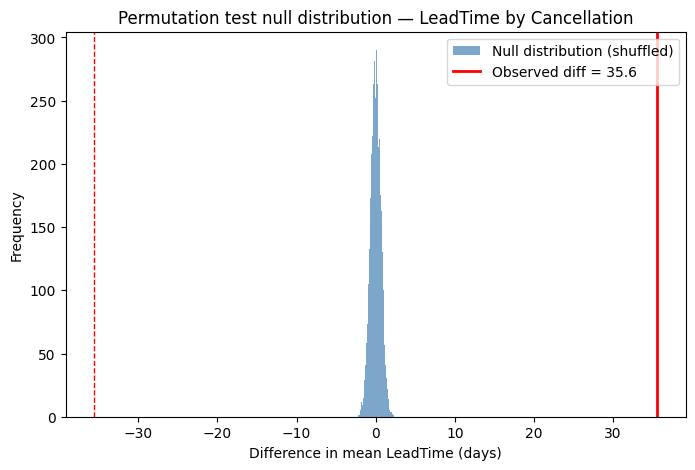

In [13]:
plt.hist(diffs, bins=50, color="steelblue", alpha=0.7, label="Null distribution (shuffled)")
plt.axvline(observed_diff, color="red", linewidth=2, label=f"Observed diff = {observed_diff:.1f}")
plt.axvline(-observed_diff, color="red", linewidth=1, linestyle="--")
plt.xlabel("Difference in mean LeadTime (days)")
plt.ylabel("Frequency")
plt.title("Permutation test null distribution — LeadTime by Cancellation")
plt.legend()
plt.savefig(f"{FIG_DIR}/permutation_leadtime.png", bbox_inches="tight", dpi=120)
plt.show()

**Result:** Observed diff = 35.62 days, corrected p-value = 0.00020 → significant. Cancelled bookings booked ~35.6 days further ahead.


## 5. Linear Regression — ADR (Average Daily Rate)
- Response: ADR
- Goal: explain price variation, not build a pricing engine


In [14]:
df["ADR"].describe()

count    87396.000000
mean       106.338229
std         55.012707
min          0.000000
25%         72.000000
50%         98.100000
75%        134.000000
max       5400.000000
Name: ADR, dtype: float64

In [15]:

print("Rows with ADR <= 0:", (df["ADR"] <= 0).sum())
print("Rows with ADR > 1000:", (df["ADR"] > 1000).sum())
df[df["ADR"] > 1000][["Hotel", "ADR", "ReservedRoomType", "MarketSegment"]]

Rows with ADR <= 0: 1778
Rows with ADR > 1000: 1


,Hotel,ADR,ReservedRoomType,MarketSegment
38749,City Hotel,5400.0,A,Offline TA/TO


**Cleaning note:** Excluded 1,778 zero-ADR observations and one extreme ADR observation (ADR=5400) from the regression dataset. Zero-ADR rows were kept in the cleaned dataset overall, just excluded here since ADR is the modeled value. Final: 85,617 rows.


In [16]:
df_reg = df[(df["ADR"] > 0) & (df["ADR"] < 1000)].copy()
print(f"Rows used for regression: {len(df_reg)} (excluded {len(df) - len(df_reg)})")

Rows used for regression: 85617 (excluded 1779)


In [17]:
predictors = ["Hotel", "ArrivalDateYear", "ArrivalDateMonth", "ReservedRoomType", "MarketSegment",
              "CustomerType", "LeadTime", "IsRepeatedGuest", "BookingChanges",
              "RequiredCarParkingSpaces", "TotalOfSpecialRequests"]

for extra in ["TotalNights", "TotalGuests"]:
    if extra in df_reg.columns:
        predictors.append(extra)

predictors = [p for p in predictors if p in df_reg.columns]
print("Predictors used:", predictors)

categorical_predictors = ["Hotel", "ArrivalDateYear", "ArrivalDateMonth",
                           "ReservedRoomType", "MarketSegment", "CustomerType"]
categorical_predictors = [c for c in categorical_predictors if c in predictors]

X = pd.get_dummies(df_reg[predictors], columns=categorical_predictors, drop_first=True)
X = sm.add_constant(X.astype(float))
y = df_reg["ADR"].astype(float)

model = sm.OLS(y, X).fit()
print(model.summary())


Predictors used: ['Hotel', 'ArrivalDateYear', 'ArrivalDateMonth', 'ReservedRoomType', 'MarketSegment', 'CustomerType', 'LeadTime', 'IsRepeatedGuest', 'BookingChanges', 'RequiredCarParkingSpaces', 'TotalOfSpecialRequests', 'TotalNights', 'TotalGuests']
                            OLS Regression Results                            
Dep. Variable:                    ADR   R-squared:                       0.603
Model:                            OLS   Adj. R-squared:                  0.602
Method:                 Least Squares   F-statistic:                     3328.
Date:                Mon, 28 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:37:37   Log-Likelihood:            -4.1730e+05
No. Observations:               85617   AIC:                         8.347e+05
Df Residuals:                   85577   BIC:                         8.351e+05
Df Model:                          39                                         
Covariance Type:            nonrobust

**Result:** R² = 0.603 (up from 0.577 after adding ArrivalDateYear). Key effects: August +50.48, RoomType H +67.71, TotalGuests +13.73, Year 2017 +29.49, Resort Hotel −17.55.

**HC3 robust SEs:** Same coefficients/R² as plain OLS, but standard errors recalculated to stay valid under heteroscedasticity (seen in residual plot below). Safer numbers to report.


In [18]:
# Heteroscedasticity-robust standard errors (HC3) -- residual plot below shows
# a funnel shape (non-constant variance), so plain OLS SEs may be unreliable.
model_hc3 = sm.OLS(y, X).fit(cov_type="HC3")
print(model_hc3.summary())


                            OLS Regression Results                            
Dep. Variable:                    ADR   R-squared:                       0.603
Model:                            OLS   Adj. R-squared:                  0.602
Method:                 Least Squares   F-statistic:                     3326.
Date:                Mon, 28 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:38:52   Log-Likelihood:            -4.1730e+05
No. Observations:               85617   AIC:                         8.347e+05
Df Residuals:                   85577   BIC:                         8.351e+05
Df Model:                          39                                         
Covariance Type:                  HC3                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

**Model comparison:** Simple model (Hotel only) vs full model, using R² and adjusted R².


In [19]:
# Simple baseline model vs full model
X_simple = pd.get_dummies(df_reg[["Hotel"]], drop_first=True)
X_simple = sm.add_constant(X_simple.astype(float))
model_simple = sm.OLS(y, X_simple).fit()

print("Simple model (ADR ~ Hotel only)")
print(f"R-squared: {model_simple.rsquared:.4f}  Adj. R-squared: {model_simple.rsquared_adj:.4f}")
print()
print("Full model (all predictors)")
print(f"R-squared: {model.rsquared:.4f}  Adj. R-squared: {model.rsquared_adj:.4f}")


Simple model (ADR ~ Hotel only)
R-squared: 0.0137  Adj. R-squared: 0.0137

Full model (all predictors)
R-squared: 0.6026  Adj. R-squared: 0.6024


**Result:** Simple model (Hotel only) R² = 0.0137. Full model R² = 0.6026. Hotel alone barely explains ADR -- the other predictors do almost all the work.

**Prediction example:** actual vs. predicted ADR for one real booking, using the fitted model.


In [20]:
example_idx = 0
print("Actual ADR:   ", y.iloc[example_idx])
print("Predicted ADR:", model.predict(X.iloc[[example_idx]]).iloc[0])


Actual ADR:    75.0
Predicted ADR: 91.09447471659554


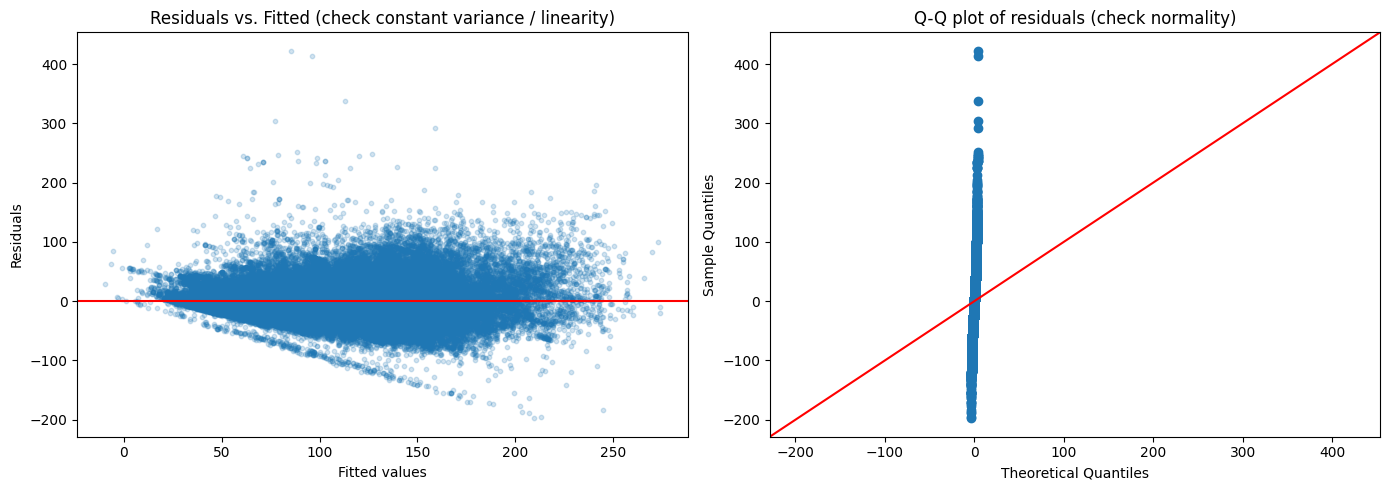

In [21]:
fitted = model.fittedvalues
resid = model.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(fitted, resid, alpha=0.2, s=10)
axes[0].axhline(0, color="red")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs. Fitted (check constant variance / linearity)")

sm.qqplot(resid, line="45", ax=axes[1])
axes[1].set_title("Q-Q plot of residuals (check normality)")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/adr_residual_diagnostics.png", dpi=120)
plt.show()

**Assumption check:** Funnel shape in residuals → heteroscedasticity. Q-Q plot deviates from normal. Regression is associative, not causal. 


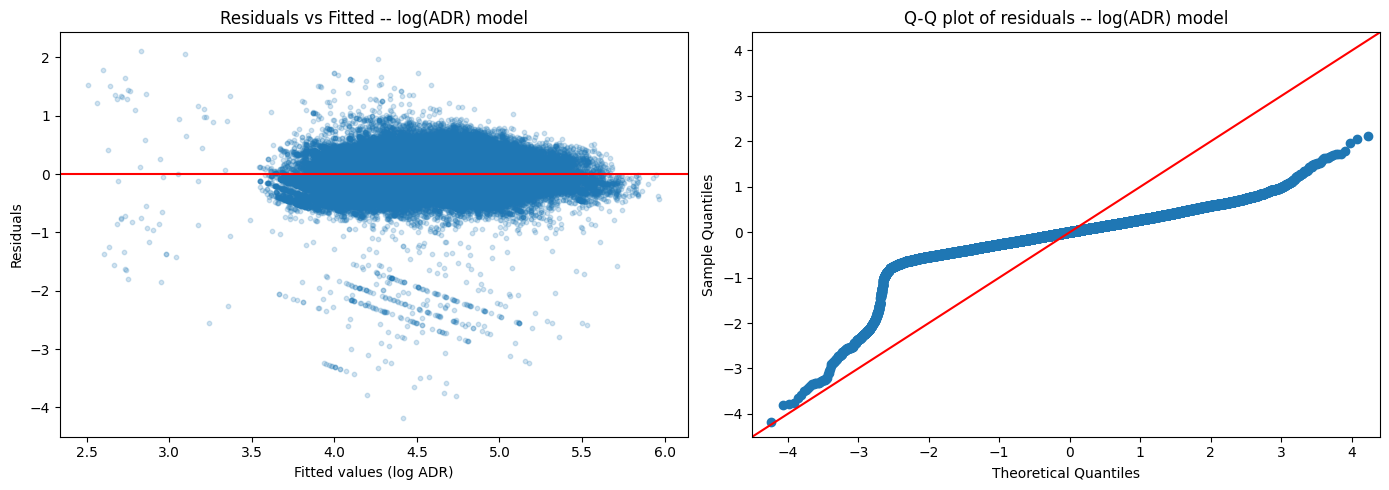

R² (log model): 0.5873850592219219


In [22]:
import numpy as np
y_log = np.log1p(df_reg["ADR"])
model_log = sm.OLS(y_log, X).fit()
resid_log = model_log.resid
fitted_log = model_log.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(fitted_log, resid_log, alpha=0.2, s=10)
axes[0].axhline(0, color="red")
axes[0].set_xlabel("Fitted values (log ADR)")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted -- log(ADR) model")

sm.qqplot(resid_log, line="45", ax=axes[1])
axes[1].set_title("Q-Q plot of residuals -- log(ADR) model")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/adr_log_residual_diagnostics.png", dpi=120)
plt.show()

print("R\u00b2 (log model):", model_log.rsquared)


**Log transform tried:** R² and Q-Q plot above (now shown for the log model too, not just claimed) -- see whether normality actually improved.


## 6. Summary

| Test | Statistic | p-value | Result |
|---|---|---|---|
| Chi-sq: Hotel × Cancel | χ²=447.664 | 2.3e-99 | Significant (Cramér's V=0.0716) |
| Chi-sq: Deposit × Cancel | χ²=2380.996 | ≈0 | Significant (Cramér's V=0.1651) |
| Permutation: LeadTime | diff=35.62d | 0.00020 | Significant |
| OLS Regression: ADR (simple) | R²=0.0137 | — | Hotel alone: weak |
| OLS Regression: ADR (full) | R²=0.603 | — | See doc for coefficients |

All results = association, not causation.
